# Research Question 1: Reporting Volume Over Time

<div style="background-color:#f0f4f8; padding:15px; border-left:6px solid #2f5597; border-radius:6px;">

## Research Question

How has the number of ZüriWieNeu reports changed over time?

## Goal of this notebook

The goal of this notebook is to analyse how the total number of infrastructure reports submitted through ZüriWieNeu has changed from the beginning of the platform in 2013 to the most recent year 2026. 

The analysis is conducted through two different approaches: 
- yearly trend: using report data from 2014 to 2025, as these years are complete calendar years and make the comparison meaningful
- monthly trend: inclusion of both 2013 and 2026, as the monthly trend is not dependent on complete calendar years

## Why this question is relevant

ZüriWieNeu is a reporting platform where residents can report problems in public infrastructure, such as damaged streets, broken streetlights, graffiti, or waste-related issues. Analysing the number of reports over time can show whether public use of the platform has increased, decreased, or remained stable.

An increase in reports does not necessarily mean that the city has more infrastructure problems. It may also reflect higher awareness of the platform, easier access through digital tools, or changing reporting behaviour among residents.

## Planned analysis

In this notebook, I will:

1. Load the raw ZüriWieNeu CSV data.
2. Clean the dataset using reusable functions from the `src` folder.
3. Yearly trend analysis
    - filter the data to complete calendar years from 2014 to 2025
    - apply the `count_reports_per_year` function
    - visualise the yearly counts as a bar chart
4. Monthly trend analysis
    - use the cleaned data set
    - apply the `count_reports_per_month` function
    - visualise the monthly counts as a line graph
5. Interpret the two analysis approaches of the report counts

In [4]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

data_dir      = Path("../data")
raw_dir       = data_dir / "raw"
processed_dir = data_dir / "processed"

In [5]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

from src.loading import load_csv_data
from src.cleaning import clean_reports
from src.analysis import count_reports_by_year, count_reports_by_month

In [6]:
# loading and cleaning the report data
df_raw = load_csv_data(raw_dir / "stzh.zwn_meldungen_p.csv")
df_cleaned = clean_reports(df_raw)

### Analysis period for yearly trend
In the following analysis, the DataFrame is shortened to only reports from the years 2014 to 2025. This decision was done to only include years containing 12 months of report data available. As the data started in 2013 in March, this condition is not fulfilled and 2026 is not complete yet.  When having a visualisation depending on bar height, this would trick a reader into thinking that there were less reports in 2013, while it was simply not a whole year of 12 months

In [12]:
# filtering data to the analysis period
df_full_years = df_cleaned[df_cleaned["year"].between(2014, 2025)]

# counting the reports per year for a first quantitative overview
yearly_counts = count_reports_by_year(df_full_years)

print(f"Yearly counts from {df_full_years["year"].min()} to {df_full_years["year"].max()}:")
display(yearly_counts)

Yearly counts from 2014 to 2025:


,year,report_count
0,2014,2139
1,2015,1943
2,2016,2307
3,2017,2869
4,2018,3724
5,2019,5243
6,2020,4802
7,2021,5783
8,2022,6828
9,2023,8325


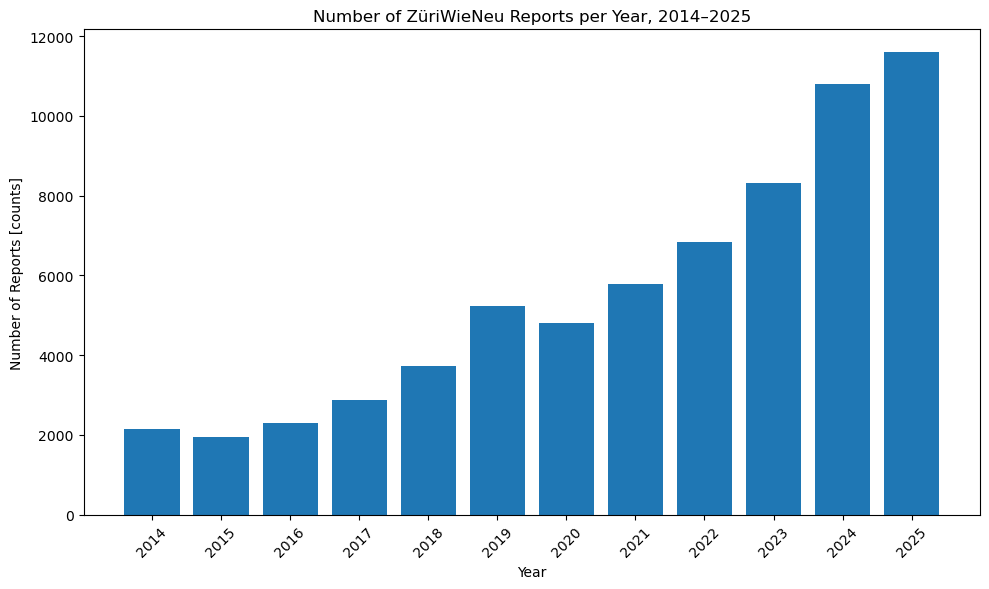

In [17]:
# visualisation of the yearly counts of report data between 2014 and 2025
plt.figure(figsize=(10, 6))

plt.bar(
    yearly_counts["year"],
    yearly_counts["report_count"]
)

plt.title("Number of ZüriWieNeu Reports per Year, 2014–2025")
plt.xlabel("Year")
plt.ylabel("Number of Reports [counts]")
plt.xticks(yearly_counts["year"], rotation=45) 

plt.tight_layout()
plt.savefig("../outputs/R1_YearlyReport_BarChart.png", bbox_inches="tight")
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of the yearly trend

The bar chart shows that the number of ZüriWieNeu reports increased strongly over the study period.

After a small decline between 2014 and 2015, the number of reports began to rise again from 2016 onward. The increase becomes especially visible after 2018. In 2018, there were 3,724 reports, while in 2025 there were 11,588 reports. This means that the yearly number of reports more than tripled between 2018 and 2025.

Overall, the results suggest that ZüriWieNeu has become much more frequently used over time. However, this does not necessarily mean that Zurich experienced more infrastructure damage. The increase may also be connected to greater awareness of the platform, changes in reporting behaviour, or easier access through digital tools.

### Analysis period of monthly trend

In the following, the analysis of monthly trends includes in addition to the years 2014-2025 the two years 2013 and 2026. As a monthly analysis is also applicable on non-completed years, this creates the opportunity to better understand which months peak in reports and how the overall trend looks like on a finer scale. 

In [18]:
# aggregate the reports by month, refering back to the cleaned dataset
monthly_counts = count_reports_by_month(df_cleaned)

# show both the first and last months of the dataset to ensure completeness of all months being included
display(monthly_counts.head())
display(monthly_counts.tail())

,year_month,report_count
0,2013-03-01,23
1,2013-04-01,563
2,2013-05-01,520
3,2013-06-01,362
4,2013-07-01,340


,year_month,report_count
153,2025-12-01,738
154,2026-01-01,789
155,2026-02-01,762
156,2026-03-01,915
157,2026-04-01,855


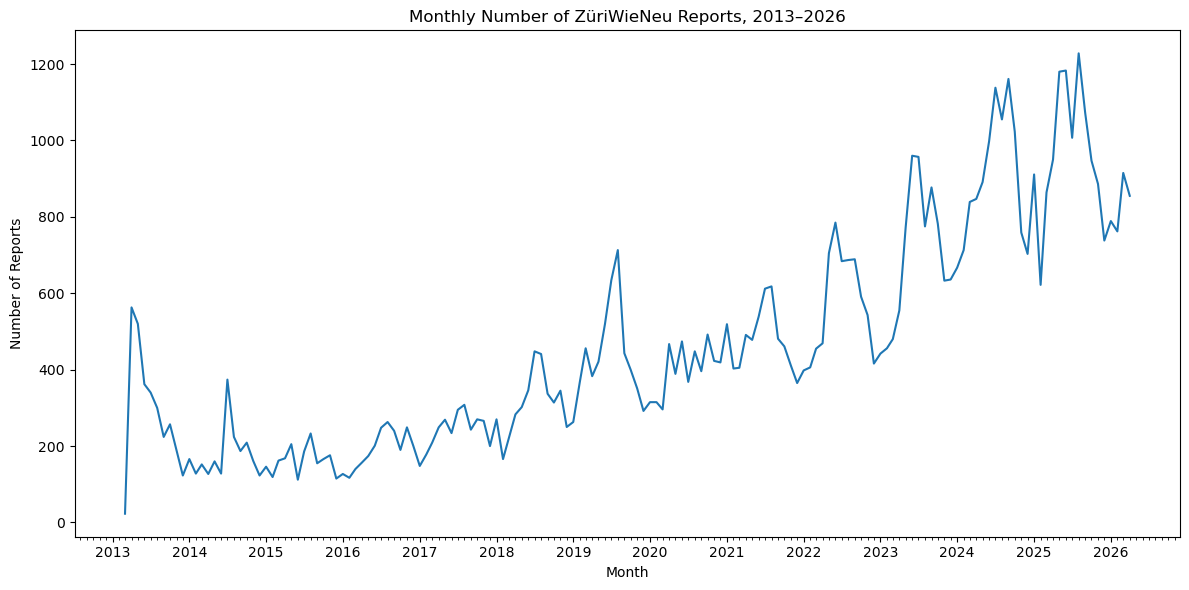

In [19]:
# create the visualisation of the monthly report counts
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_counts["year_month"],
    monthly_counts["report_count"]
)

plt.title("Monthly Number of ZüriWieNeu Reports, 2013–2026")
plt.xlabel("Month")
plt.ylabel("Number of Reports")

# yearly labels on major ticks for readability; monthly minor ticks make the aggregation level visible.
# Major ticks: one label per year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Minor ticks: one small dash per month
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig("../outputs/R1_MonthlyNumbers.png", bbox_inches="tight")
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of the monthly trend

The monthly time-series plot shows the development of ZüriWieNeu reports in more detail than the yearly bar chart.

The overall trend confirms that reporting activity increased strongly over time, especially from around 2018 onward. The monthly view also shows that the increase was not completely smooth. Instead, there are repeated short-term peaks and declines, which may reflect seasonal effects, specific local events, changes in reporting behaviour, or increased platform visibility.

The monthly ticks on the x-axis make clear that the data is aggregated by month, while the yearly labels keep the chart readable.

<div style="background-color:#eef9f0; padding:15px; border-left:6px solid #3c9d5d; border-radius:6px;">

## Conclusion

This notebook analysed how the number of ZüriWieNeu reports changed over time between 2013 and 2026.

The yearly analysis shows a clear long-term increase in reporting activity. After a decline between 2014 and 2015, the number of reports started to rise again from 2016 onward. The growth became especially strong after 2018, increasing from 3,724 reports in 2018 to 11,588 reports in 2025.

The monthly time-series analysis confirms this overall upward trend, while also showing short-term fluctuations within individual years. These monthly changes suggest that reporting activity is not evenly distributed throughout the year and may be influenced by seasonal patterns, specific incidents, or changes in public use of the platform.

Overall, the results suggest that ZüriWieNeu has become increasingly used as a reporting tool for urban infrastructure problems in Zurich. However, the growing number of reports should not automatically be interpreted as a direct increase in infrastructure damage. It may also reflect greater awareness of the platform, easier access to digital reporting tools, or changing reporting behaviour among residents.

For this reason, the results are best understood as an indicator of both urban infrastructure issues and public engagement with the reporting platform.